# 03 — Signal Comparison: Old vs New (v7)

Compares the original signal (`data/Old_signal.csv`) with the current v7 keyword-filter EPU-style signal (`data/interim/monthly_signal.csv`).

**Old signal:** `Average_Signal_Score` — unnormalised, earlier methodology (pre-EPU rewrite)  
**New signal:** `net_hawkish_z` — keyword fiscal filter (v7), EPU paragraph counting `(H−D)/P`, winsorised, z-scored cross-president  

Both are z-scored here for direct comparability.

## 1. Setup & data loading

In [12]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from scipy import stats

_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

PRES_ORDER  = ['Macri', 'AF', 'Milei']
PRES_COLORS = {'Macri': '#2196F3', 'AF': '#4CAF50', 'Milei': '#FF5722'}
PRES_LABELS = {'Macri': 'Macri (2015–2019)', 'AF': 'A. Fernández (2019–2023)', 'Milei': 'Milei (2023–2026)'}
INAUG = ['2019-12-10', '2023-12-10']

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})

# ── Load old signal ──────────────────────────────────────────────────────────
old = pd.read_csv(os.path.join(_ROOT, 'data', 'Old_signal.csv'))
old['date'] = pd.to_datetime(old['Month'], dayfirst=True)
old['year_month'] = old['date'].dt.to_period('M').astype(str)
old = old[['year_month', 'Average_Signal_Score']].rename(columns={'Average_Signal_Score': 'old_raw'})
# Z-score old signal for comparability
old['old_z'] = (old['old_raw'] - old['old_raw'].mean()) / old['old_raw'].std()

# ── Load new signal ──────────────────────────────────────────────────────────
new = pd.read_csv(os.path.join(_ROOT, 'data', 'interim', 'monthly_signal.csv'))
new = new[['year_month', 'president', 'net_hawkish_z', 'net_hawkish_z_raw', 'H_t', 'D_t', 'n_fiscal_paras']]

# ── Merge on year_month ──────────────────────────────────────────────────────
df = new.merge(old, on='year_month', how='left')
df['ym_dt'] = pd.to_datetime(df['year_month'])
df = df.sort_values('ym_dt').reset_index(drop=True)

print(f'Merged rows   : {len(df)}')
print(f'Old signal NaN: {df["old_z"].isna().sum()} (months in new but not old)')
print(f'New signal NaN: {df["net_hawkish_z"].isna().sum()} (zero fiscal paragraphs)')
print(f'Both valid    : {df[["old_z","net_hawkish_z"]].dropna().shape[0]}')
df[['year_month','president','net_hawkish_z','old_z']].head(6)

Merged rows   : 127
Old signal NaN: 0 (months in new but not old)
New signal NaN: 3 (zero fiscal paragraphs)
Both valid    : 124


,year_month,president,net_hawkish_z,old_z
0,2015-12,Macri,0.200120,-0.048710
1,2016-01,Macri,NaN,0.193070
2,2016-02,Macri,1.065992,-0.259620
3,2016-03,Macri,-0.164457,-0.217447
4,2016-04,Macri,0.373295,-0.300095
5,2016-05,Macri,0.892818,-0.034686


## 2. Summary statistics — old vs new

In [13]:
print(f'{'':30s}  {'Old (z-scored)':>16s}  {'New net_hawkish_z':>18s}')
print('─' * 70)
for pres in PRES_ORDER:
    g = df[df['president'] == pres]
    o = g['old_z'].dropna()
    n = g['net_hawkish_z'].dropna()
    print(f'{pres:30s}  N={len(o):>2d}  mean={o.mean():+.3f}  std={o.std():.3f}  |  N={len(n):>2d}  mean={n.mean():+.3f}  std={n.std():.3f}')

print()
valid = df.dropna(subset=['old_z', 'net_hawkish_z'])
r_p, p_val = stats.pearsonr(valid['old_z'], valid['net_hawkish_z'])
r_s, _ = stats.spearmanr(valid['old_z'], valid['net_hawkish_z'])
print(f'Overall Pearson  r : {r_p:.4f}  (p={p_val:.4f})')
print(f'Overall Spearman ρ : {r_s:.4f}')

                                  Old (z-scored)   New net_hawkish_z
──────────────────────────────────────────────────────────────────────
Macri                           N=49  mean=-0.340  std=0.317  |  N=48  mean=+0.247  std=0.648
AF                              N=49  mean=-0.634  std=0.384  |  N=47  mean=-0.905  std=0.609
Milei                           N=29  mean=+1.665  std=0.565  |  N=29  mean=+1.058  std=0.663

Overall Pearson  r : 0.6220  (p=0.0000)
Overall Spearman ρ : 0.6271


## 3. Full-panel time series overlay

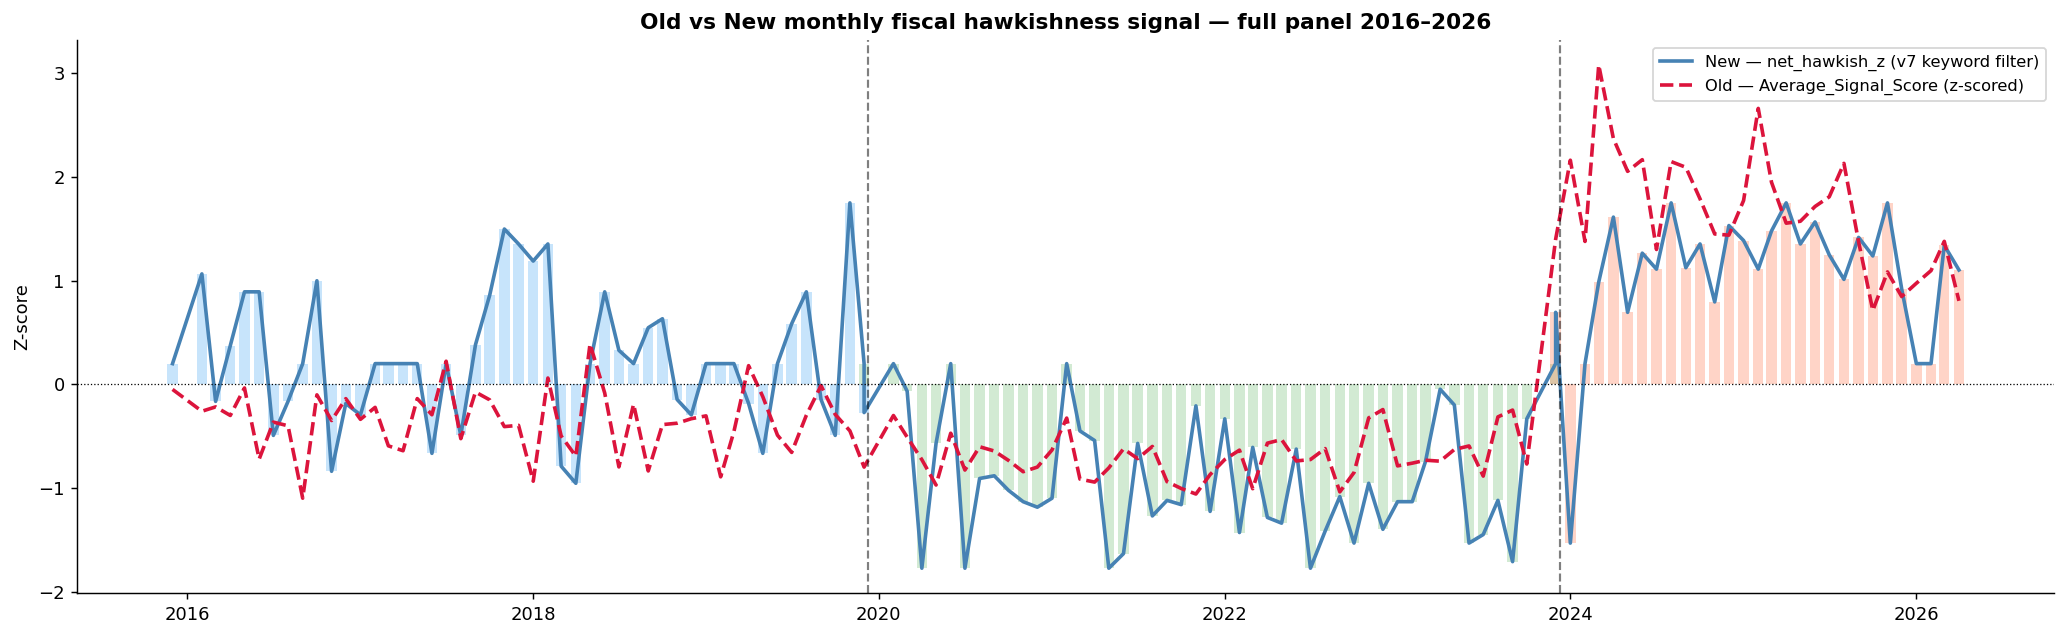

In [14]:
fig, ax = plt.subplots(figsize=(16, 5))

valid = df.dropna(subset=['old_z', 'net_hawkish_z'])

# Colour bars by president
for pres in PRES_ORDER:
    g = df[df['president'] == pres]
    ax.bar(g['ym_dt'], g['net_hawkish_z'].fillna(0),
           color=PRES_COLORS[pres], alpha=0.25, width=22)

ax.plot(valid['ym_dt'], valid['net_hawkish_z'],
        color='steelblue', lw=2, label='New — net_hawkish_z (v7 keyword filter)')
ax.plot(valid['ym_dt'], valid['old_z'],
        color='crimson', lw=2, ls='--', label='Old — Average_Signal_Score (z-scored)')
ax.axhline(0, color='black', lw=0.7, ls=':')
for d in INAUG:
    ax.axvline(pd.Timestamp(d), color='black', lw=1.2, ls='--', alpha=0.5)

ax.set_ylabel('Z-score')
ax.set_title('Old vs New monthly fiscal hawkishness signal — full panel 2016–2026', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Per-president time series

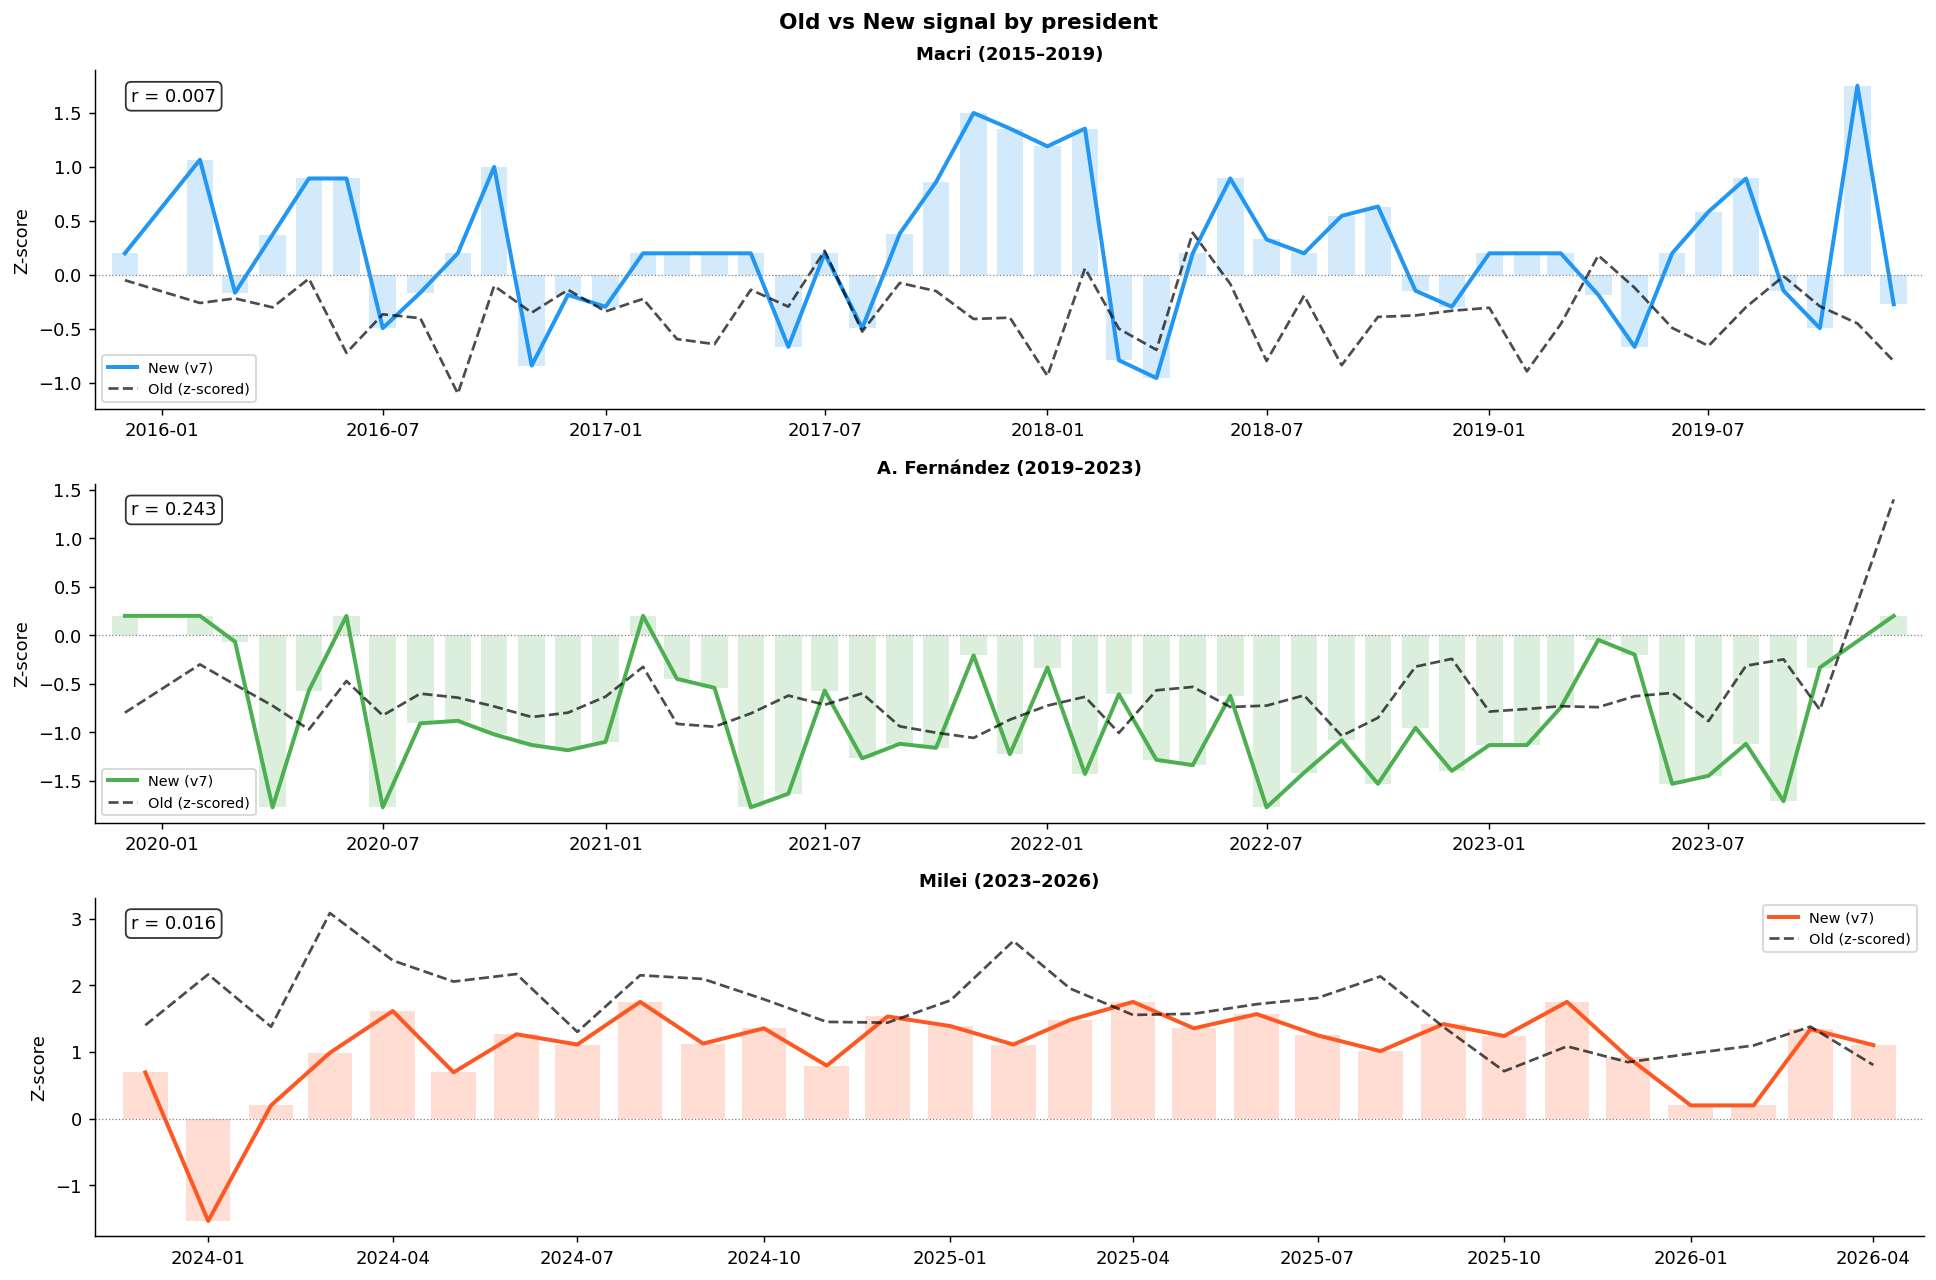

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=False)

for ax, pres in zip(axes, PRES_ORDER):
    g = df[df['president'] == pres].sort_values('ym_dt')
    v = g.dropna(subset=['old_z', 'net_hawkish_z'])

    ax.bar(g['ym_dt'], g['net_hawkish_z'].fillna(0),
           color=PRES_COLORS[pres], alpha=0.2, width=22)
    ax.plot(v['ym_dt'], v['net_hawkish_z'],
            color=PRES_COLORS[pres], lw=2.2, label='New (v7)')
    ax.plot(v['ym_dt'], v['old_z'],
            color='black', lw=1.5, ls='--', alpha=0.7, label='Old (z-scored)')
    ax.axhline(0, color='grey', lw=0.7, ls=':')

    # Correlation annotation
    if len(v) > 2:
        r, _ = stats.pearsonr(v['net_hawkish_z'], v['old_z'])
        ax.text(0.02, 0.95, f'r = {r:.3f}', transform=ax.transAxes,
                va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_title(PRES_LABELS[pres], fontsize=10, fontweight='bold')
    ax.set_ylabel('Z-score')
    ax.legend(fontsize=8)
    ax.set_xlim(g['ym_dt'].min() - pd.Timedelta(days=25),
                g['ym_dt'].max() + pd.Timedelta(days=25))

plt.suptitle('Old vs New signal by president', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Correlation scatter — overall and by president

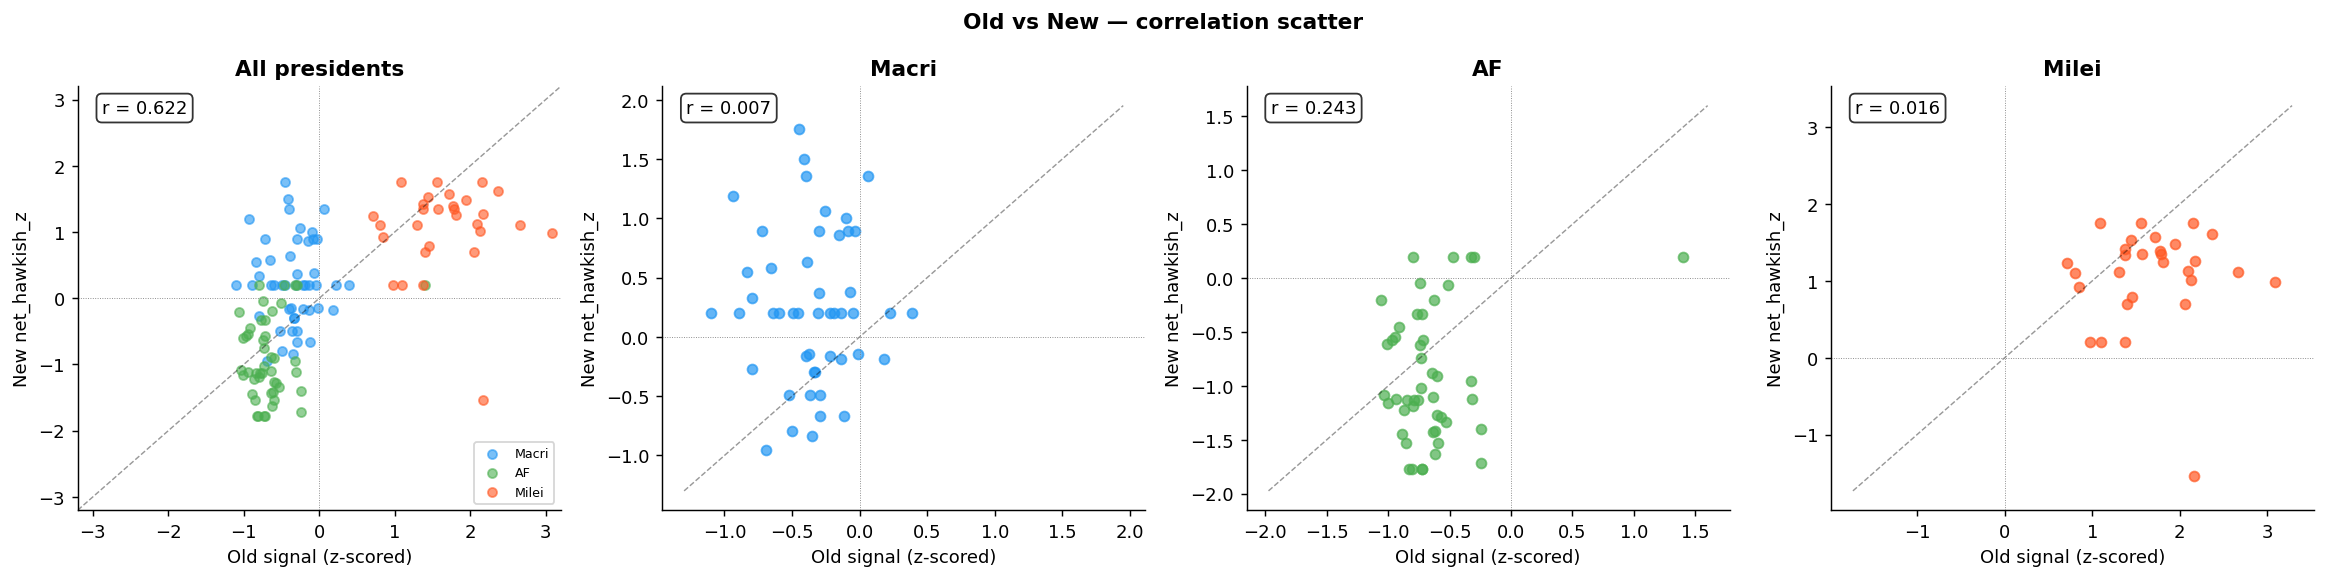

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

# Panel 1: all presidents
ax = axes[0]
valid = df.dropna(subset=['old_z', 'net_hawkish_z'])
for pres in PRES_ORDER:
    g = valid[valid['president'] == pres]
    ax.scatter(g['old_z'], g['net_hawkish_z'],
               c=PRES_COLORS[pres], alpha=0.6, s=25, label=pres)
r, _ = stats.pearsonr(valid['old_z'], valid['net_hawkish_z'])
lims = [-3.2, 3.2]
ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.4)
ax.axhline(0, color='grey', lw=0.5, ls=':')
ax.axvline(0, color='grey', lw=0.5, ls=':')
ax.text(0.05, 0.97, f'r = {r:.3f}', transform=ax.transAxes, va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('Old signal (z-scored)')
ax.set_ylabel('New net_hawkish_z')
ax.set_title('All presidents', fontweight='bold')
ax.legend(fontsize=7)
ax.set_xlim(lims); ax.set_ylim(lims)

# Panels 2-4: per president
for ax, pres in zip(axes[1:], PRES_ORDER):
    g = valid[valid['president'] == pres]
    ax.scatter(g['old_z'], g['net_hawkish_z'],
               c=PRES_COLORS[pres], alpha=0.7, s=30)
    if len(g) > 2:
        r_p, _ = stats.pearsonr(g['old_z'], g['net_hawkish_z'])
        lo = min(g['old_z'].min(), g['net_hawkish_z'].min()) - 0.2
        hi = max(g['old_z'].max(), g['net_hawkish_z'].max()) + 0.2
        ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.4)
        ax.text(0.05, 0.97, f'r = {r_p:.3f}', transform=ax.transAxes, va='top', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.axhline(0, color='grey', lw=0.5, ls=':')
    ax.axvline(0, color='grey', lw=0.5, ls=':')
    ax.set_xlabel('Old signal (z-scored)')
    ax.set_ylabel('New net_hawkish_z')
    ax.set_title(pres, fontweight='bold')

plt.suptitle('Old vs New — correlation scatter', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Rolling 6-month correlation — how agreement varies over time

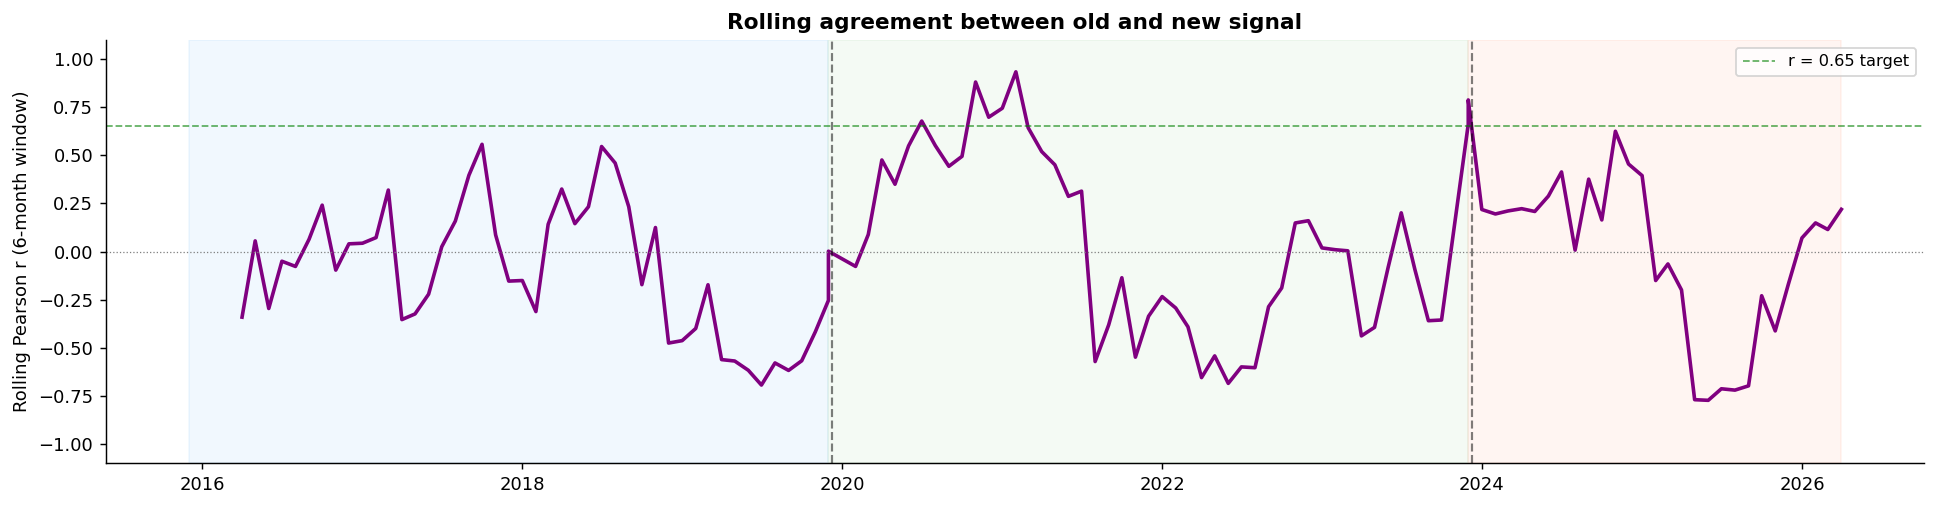

In [17]:
valid = df.dropna(subset=['old_z', 'net_hawkish_z']).set_index('ym_dt').sort_index()

rolling_r = valid['old_z'].rolling(6, min_periods=4).corr(valid['net_hawkish_z'])

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(rolling_r.index, rolling_r.values, color='purple', lw=2)
ax.axhline(0, color='grey', lw=0.7, ls=':')
ax.axhline(0.65, color='green', lw=1, ls='--', alpha=0.6, label='r = 0.65 target')
for d in INAUG:
    ax.axvline(pd.Timestamp(d), color='black', lw=1.2, ls='--', alpha=0.5)
for pres in PRES_ORDER:
    g = df[df['president'] == pres]
    ax.axvspan(g['ym_dt'].min(), g['ym_dt'].max(),
               color=PRES_COLORS[pres], alpha=0.06)
ax.set_ylabel('Rolling Pearson r (6-month window)')
ax.set_title('Rolling agreement between old and new signal', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(-1.1, 1.1)
plt.tight_layout()
plt.show()

## 7. Direction agreement — do they agree on hawkish vs dovish?

In [18]:
valid = df.dropna(subset=['old_z', 'net_hawkish_z']).copy()
valid['old_dir'] = np.sign(valid['old_z'])
valid['new_dir'] = np.sign(valid['net_hawkish_z'])
valid['agree'] = valid['old_dir'] == valid['new_dir']

agree_rate = valid['agree'].mean()
print(f'Overall direction agreement: {agree_rate*100:.1f}%  ({valid["agree"].sum()}/{len(valid)} months)\n')

print(f'{"President":8s}  {"N":>4s}  {"Agree %":>8s}  {"Old mean-z":>10s}  {"New mean-z":>10s}')
print('─' * 55)
for pres in PRES_ORDER:
    g = valid[valid['president'] == pres]
    print(f'{pres:8s}  {len(g):>4d}  {g["agree"].mean()*100:>7.1f}%  '
          f'{g["old_z"].mean():>+10.3f}  {g["net_hawkish_z"].mean():>+10.3f}')

# Confusion matrix
print('\nDirection confusion matrix (old rows, new cols):')
ct = pd.crosstab(
    valid['old_dir'].map({-1:'Dovish', 0:'Neutral', 1:'Hawkish'}),
    valid['new_dir'].map({-1:'Dovish', 0:'Neutral', 1:'Hawkish'}),
    margins=True
)
print(ct)

Overall direction agreement: 72.6%  (90/124 months)

President     N   Agree %  Old mean-z  New mean-z
───────────────────────────────────────────────────────
Macri       48     39.6%      -0.351      +0.247
AF          47     91.5%      -0.654      -0.905
Milei       29     96.6%      +1.665      +1.058

Direction confusion matrix (old rows, new cols):
new_dir  Dovish  Hawkish  All
old_dir                      
Dovish       58       32   90
Hawkish       2       32   34
All          60       64  124


## 8. Biggest disagreements — months where signals diverge most

In [19]:
valid = df.dropna(subset=['old_z', 'net_hawkish_z']).copy()
valid['divergence'] = (valid['net_hawkish_z'] - valid['old_z']).abs()
valid['direction_flip'] = np.sign(valid['old_z']) != np.sign(valid['net_hawkish_z'])

print('=== TOP 15 MONTHS BY SIGNAL DIVERGENCE ===')
print(f'{"Month":>10s}  {"President":>8s}  {"Old-z":>8s}  {"New-z":>8s}  {"Diff":>8s}  {"Flip?":>6s}')
print('─' * 60)
for _, row in valid.nlargest(15, 'divergence').iterrows():
    flip = '*** FLIP' if row['direction_flip'] else ''
    print(f'{row["year_month"]:>10s}  {row["president"]:>8s}  '
          f'{row["old_z"]:>+8.3f}  {row["net_hawkish_z"]:>+8.3f}  '
          f'{row["divergence"]:>8.3f}  {flip}')

=== TOP 15 MONTHS BY SIGNAL DIVERGENCE ===
     Month  President     Old-z     New-z      Diff   Flip?
────────────────────────────────────────────────────────────
   2024-01     Milei    +2.163    -1.532     3.694  *** FLIP
   2019-11     Macri    -0.449    +1.751     2.200  *** FLIP
   2018-01     Macri    -0.935    +1.190     2.124  *** FLIP
   2024-03     Milei    +3.082    +0.987     2.094  
   2017-11     Macri    -0.408    +1.499     1.907  *** FLIP
   2017-12     Macri    -0.395    +1.355     1.750  *** FLIP
   2016-06     Macri    -0.721    +0.893     1.614  *** FLIP
   2025-02     Milei    +2.663    +1.112     1.551  
   2023-09        AF    -0.248    -1.711     1.463  
   2018-09     Macri    -0.836    +0.546     1.382  *** FLIP
   2024-05     Milei    +2.055    +0.695     1.360  
   2016-02     Macri    -0.260    +1.066     1.326  *** FLIP
   2016-09     Macri    -1.098    +0.200     1.299  *** FLIP
   2018-02     Macri    +0.061    +1.355     1.293  
   2019-07     Macri  

## 9. President mean comparison — did the ordering change?

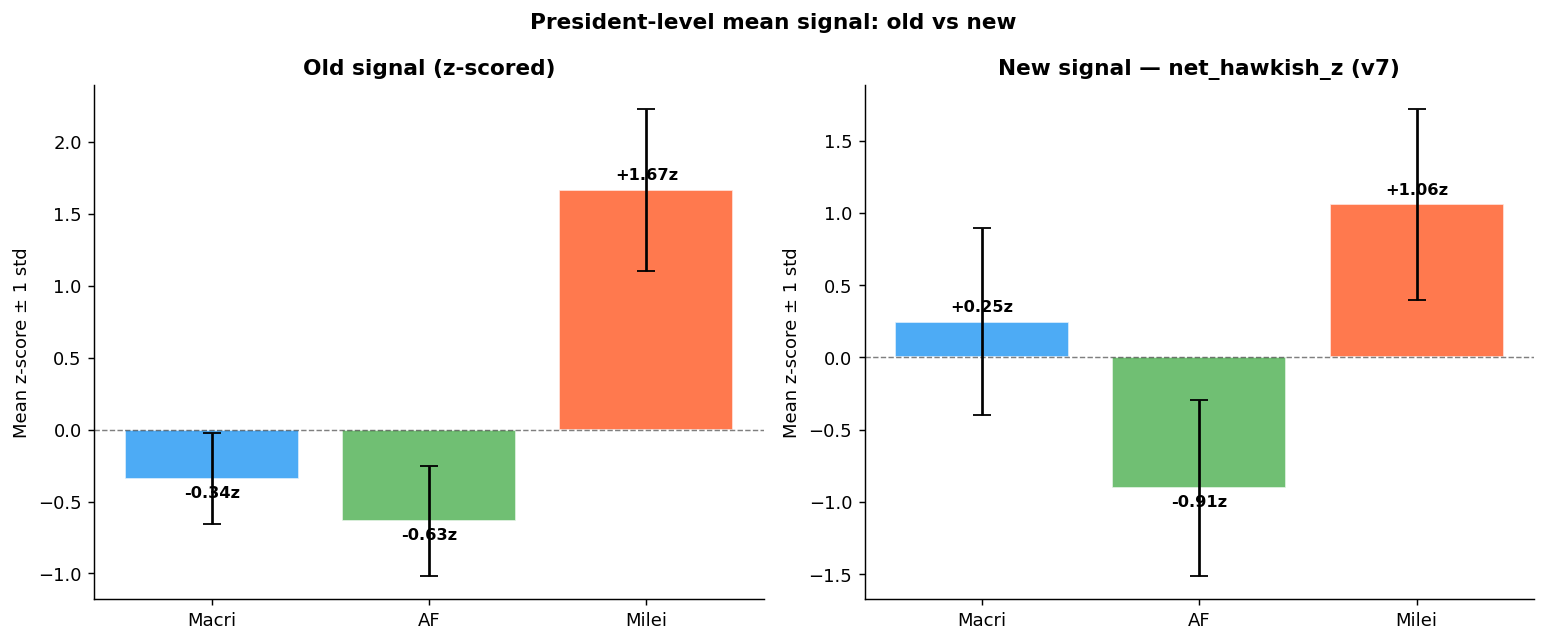

President ordering:
  Old : Milei > Macri > AF
  New : Milei > Macri > AF


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(axes,
                           ['old_z', 'net_hawkish_z'],
                           ['Old signal (z-scored)', 'New signal — net_hawkish_z (v7)']):
    means = [df[df['president']==p][col].mean() for p in PRES_ORDER]
    stds  = [df[df['president']==p][col].std()  for p in PRES_ORDER]
    colors = [PRES_COLORS[p] for p in PRES_ORDER]
    bars = ax.bar(PRES_ORDER, means, yerr=stds, capsize=5,
                  color=colors, alpha=0.8, edgecolor='white')
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_ylabel('Mean z-score ± 1 std')
    ax.set_title(title, fontweight='bold')
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, m + (0.05 if m >= 0 else -0.15),
                f'{m:+.2f}z', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('President-level mean signal: old vs new', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('President ordering:')
print(f'  Old : {" > ".join(sorted(PRES_ORDER, key=lambda p: df[df["president"]==p]["old_z"].mean(), reverse=True))}')
print(f'  New : {" > ".join(sorted(PRES_ORDER, key=lambda p: df[df["president"]==""+p]["net_hawkish_z"].mean(), reverse=True))}')

## 10. Summary

Key findings from the comparison:

In [21]:
valid = df.dropna(subset=['old_z', 'net_hawkish_z'])
r_p, _ = stats.pearsonr(valid['old_z'], valid['net_hawkish_z'])
r_s, _ = stats.spearmanr(valid['old_z'], valid['net_hawkish_z'])
agree  = (np.sign(valid['old_z']) == np.sign(valid['net_hawkish_z'])).mean()

old_gap = df[df['president']=='Milei']['old_z'].mean() - df[df['president']=='AF']['old_z'].mean()
new_gap = df[df['president']=='Milei']['net_hawkish_z'].mean() - df[df['president']=='AF']['net_hawkish_z'].mean()

print('=' * 65)
print('COMPARISON SUMMARY')
print('=' * 65)
print(f'Pearson r (monthly)     : {r_p:.4f}')
print(f'Spearman ρ (monthly)    : {r_s:.4f}')
print(f'Direction agreement     : {agree*100:.1f}%')
print()
print(f'Milei–AF gap  Old: {old_gap:+.3f}z   New: {new_gap:+.3f}z')
print()
print('President means:')
for pres in PRES_ORDER:
    o = df[df['president']==pres]['old_z'].mean()
    n = df[df['president']==pres]['net_hawkish_z'].mean()
    print(f'  {pres:8s}  Old: {o:+.3f}z   New: {n:+.3f}z')
print('=' * 65)

COMPARISON SUMMARY
Pearson r (monthly)     : 0.6220
Spearman ρ (monthly)    : 0.6271
Direction agreement     : 72.6%

Milei–AF gap  Old: +2.299z   New: +1.963z

President means:
  Macri     Old: -0.340z   New: +0.247z
  AF        Old: -0.634z   New: -0.905z
  Milei     Old: +1.665z   New: +1.058z
